In [29]:
from langgraph.graph import StateGraph , START , END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv

In [30]:
load_dotenv()

True

In [31]:
model = ChatGroq(
    model_name="llama-3.3-70b-versatile"
)

In [32]:
class BlogState(TypedDict):
    topic : str 
    outline : str
    blog : str

In [33]:
def outline_generate(state : BlogState) -> BlogState:
    topic = state['topic']

    prompt = f"Give me detail outline about this topics {topic}"

    outline = model.invoke(prompt)

    state['outline'] = outline

    return state

In [34]:
def blog_generate(state : BlogState) -> BlogState:
    outline = state['outline']
    topic = state['topic']
    prompt = f"Make me a blog based on  this outline {outline} based on this topic {topic}"

    blog = model.invoke(prompt)

    state['blog'] = blog

    return state

In [35]:
graph = StateGraph(BlogState)

graph.add_node("outline_generate" , outline_generate)
graph.add_node("blog_generate" , blog_generate)

graph.add_edge(START , "outline_generate")
graph.add_edge("outline_generate" , "blog_generate")
graph.add_edge("blog_generate" , END)

workflow = graph.compile()

In [38]:
initial_state = {'topic' : "The art of sun rising from the japan"}
final_state = workflow.invoke(initial_state)
print(final_state)

{'topic': 'The art of sun rising from the japan', 'outline': AIMessage(content='**The Art of Sunrise in Japan: A Cultural and Aesthetic Phenomenon**\n\nI. **Introduction**\n    A. Brief overview of Japan\'s unique cultural relationship with nature\n    B. Importance of sunrise in Japanese culture and art\n    C. Thesis statement: The art of sunrise in Japan is a multifaceted phenomenon that encompasses various art forms, cultural practices, and philosophical perspectives.\n\nII. **Historical and Cultural Context**\n    A. **Shintoism and Nature Worship**: The role of sunrise in Shinto mythology and rituals\n    B. **Zen Buddhism and Mindfulness**: The influence of Zen Buddhism on Japanese art and culture, particularly in relation to sunrise\n    C. **Seasonal Celebrations**: Japan\'s seasonal festivals and traditions, such as New Year (Oshogatsu) and Cherry Blossom Viewing (Hanami)\n\nIII. **Visual Arts and Sunrise**\n    A. **Traditional Japanese Painting**: Depictions of sunrise in t

In [39]:
final_state['blog']

AIMessage(content='**The Art of Sunrise in Japan: A Cultural and Aesthetic Phenomenon**\n\nJapan has a unique cultural relationship with nature, and the art of sunrise is a multifaceted phenomenon that encompasses various art forms, cultural practices, and philosophical perspectives. From the majestic mountains to the serene gardens, Japan\'s natural beauty has inspired countless artists, poets, and musicians to capture the essence of sunrise.\n\n**Introduction to Japan\'s Cultural Relationship with Nature**\n\nJapan\'s cultural relationship with nature is deeply rooted in its history and traditions. The country\'s indigenous religion, Shintoism, emphasizes the importance of living in harmony with nature and revering the spirits that inhabit it. This reverence for nature is reflected in Japan\'s stunning gardens, architecture, and art, which often incorporate natural elements and themes.\n\n**The Importance of Sunrise in Japanese Culture and Art**\n\nSunrise has been a significant moti

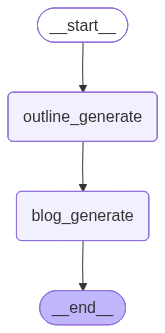

In [37]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())